In [2]:
# %pip install requests
# %pip install re

In [3]:
import pandas as pd
import json
import requests
import re
import time
import datetime

def print_full(x):
    with pd.option_context('display.max_columns', None):
        display(x)


### This notebook contains one class:
* MTScraper - Performs scraping operations for prices and for financial statements

### The data stored by the scraper:
* mt-sectors - A list of sectors, scraped from the MT sector list
* mt-industries - A list of industries, scraped from the MT industry list
* mt-tickers - A list of all tickers known by MT, with their sector and industry
* mt-prices - The tickers and historical prices, date, end of day price and volume traded that day

* mt-balance-sheet-quarterly - Balance sheet
* mt-income-statement-quarterly - Income statement
* mt-cash-flow-statement-quarterly - Cashflow statement

### Remove all other cells in this notebook
* Ideas is to simply run all cells in this notebook on a regular basis and it will automatically keep itself updated
* Reports should update everything, prices maybe it is more selective - some logic to decide which ticker prices it should scrape

### TODO
* Create some kind of tickers status file that keep a note of what's been updated, allows easily finding what to do next...
* Scrape any reports that are due - function that performs a full update, knows what's missing, updates itself, updates status file




In [4]:
class MTScraper():

    def loadTickerlist():
        MTScraper.tickerlist = pd.read_csv('MT/mt-tickers.csv', parse_dates=['last_update']).set_index('ticker')
        MTScraper.tickerlist['last_update'] = MTScraper.tickerlist['last_update'].dt.date

    def loadReports():
        MTScraper.incq = pd.read_csv('MT/mt-income-statement-quarterly.csv', parse_dates=['Quarter']).set_index(['ticker','Quarter'])
        MTScraper.balanceq = pd.read_csv('MT/mt-balance-sheet-quarterly.csv', parse_dates=['Quarter']).set_index(['ticker','Quarter'])
        MTScraper.cfq = pd.read_csv('MT/mt-cash-flow-statement-quarterly.csv', parse_dates=['Quarter']).set_index(['ticker','Quarter'])
        MTScraper.prices = pd.read_csv('MT/mt-prices.csv', parse_dates=['timestamp']).set_index(['ticker', 'timestamp'])
        MTScraper.sectors = pd.read_csv('MT/mt-sectors.csv')
        MTScraper.loadTickerlist()
        
    # updateReports - perform basic maintenance on the reports to keep the data as clean as possible
    # Add more to this as I think of extra ways to maintain
    def updateReports():
        print('Updating reports...')
        
        # Re-read the reports to ensure we're picking up the very latest version before doing anything further
        MTScraper.loadReports()
        
        # Check for and remove duplicates if any exist
        dupes = MTScraper.balanceq.index.duplicated()
        print(f'Removing {sum(dupes)} duplicates for BALANCE SHEET')
        MTScraper.balanceq = MTScraper.balanceq[ ~dupes ]
        if (sum(dupes) > 400):
            print('Writing to BALANCE SHEET file')
            MTScraper.balanceq.to_csv('MT/mt-balance-sheet-quarterly.csv')
            
        dupes = MTScraper.incq.index.duplicated()
        print(f'Removing {sum(dupes)} duplicates for INCOME STATEMENT')
        MTScraper.incq = MTScraper.incq[ ~dupes ]
        if (sum(dupes) > 200):
            print('Writing to INCOME STATEMENT file')
            MTScraper.incq.to_csv('MT/mt-income-statement-quarterly.csv')
            
        dupes = MTScraper.cfq.index.duplicated()
        print(f'Removing {sum(dupes)} duplicates for CASHFLOW STATEMENT')
        MTScraper.cfq = MTScraper.cfq[ ~dupes ]
        if (sum(dupes) > 200):
            print('Writing to CASHFLOW STATEMENT file')
            MTScraper.cfq.to_csv('MT/mt-cash-flow-statement-quarterly.csv')

        # repeat for master ticker list - updates are appended to this file so occasionally de-dupe and save
        dupes = MTScraper.tickerlist.index.duplicated(keep='last')
        print(f'Removing {sum(dupes)} duplicates for TICKERS')
        MTScraper.tickerlist = MTScraper.tickerlist[ ~dupes ]
        if (sum(dupes) > 100):
            MTScraper.tickerlist.to_csv('MT/mt-tickers.csv')
            
        # NOTE: could extend above and drop NA rows using 'thresh' to decide how many valid values before filtering
        # This shows the rows that would be removed if dropna applied with thresh to validate before doing it:
        # df.loc[df.index.difference(df.dropna(axis=0, thresh=5).index)]
        
        print('*** DONE ***')


    # scrapeAllLists
    # Performs a clean scrape of all sectors/industries/tickers of Macro Trends
    # Re-saves all data, overwriting previous...
    # data written to mt-tickers.csv - the master list of tickers that MT can supply data for
    def scrapeAllLists():
        
        sectors = MTScraper.scrapeSectors()
        sectors.to_csv('MT/mt-sectors.csv', index=False)

        industries = pd.DataFrame()
        for s, r in sectors.iterrows():
            print(s)
            ind = MTScraper.scrapeIndustries(r)
            industries = pd.concat([industries, ind])
        industries.to_csv('MT/mt-industries.csv', index=False)

        # same for master ticker list - more complex since we want to preserve update data from master list
        tickers = pd.DataFrame()
        for i, r in industries.iterrows():
            print(r['zacks_x_ind_title'])
            t = MTScraper.scrapeTickers(r)
            t['sector'] = r['zacks_x_sector_desc']
            
            tickers = pd.concat([tickers, t])
            
        # merge tickers with master list - this adds the last_update and status columns
        tickers.set_index('ticker')
        tickers.merge(MTScraper.tickerlist[['last_update','status']], left_index=True, right_index=True, how='left')
        
        # any empty values for last_update and status will be new records - initialise
        tickers['last_update'].fillna('2020-01-01')
        tickers['status'].fillna(0)
        tickers.to_csv('MT/mt-tickers-test.csv', index=False)

        print('*** DONE ***')
        
    # scrapeSectors: All Sectors at the top-level
    def scrapeSectors():
        url = 'https://www.macrotrends.net/stocks/research'
        r = requests.get(url)
        html = r.text

        # Look for this pattern: <a href='/stocks/sector/13/finance'>Finance</a>
        match = re.findall(r"<a href='/stocks/sector/(\d+)/([-\w]+)'>([a-zA-Z/ -]+)</a>", html)
        if (match):
            allsectors = []
            for sector in match:
                data = {
                'id':sector[0],
                'url':sector[1],
                'name':sector[2]
                }
                allsectors.append(data)
                print(data)
        else:
            print('Hmmm...')
        df = pd.DataFrame.from_dict(allsectors, orient='columns')
        return df

    # scrapeIndustries: All industries in a certain Sector
    # Pass in a sector record (3 items ID, URL, NAME)
    def scrapeIndustries(r):
        url = f"https://www.macrotrends.net/stocks/sector/{r['id']}/{r['url']}"
        r = requests.get(url)
        html = r.text

        parts = html.split('var data = ')
        extract = parts[1].split('\r\n')
        j = json.loads(extract[0])
        df = pd.DataFrame.from_dict(j, orient='columns')
        keep_cols =['zacks_x_sector_code','zacks_x_sector_desc','zacks_x_ind_code','zacks_x_ind_title','stock_count','market_cap','pe_ratio','ps_ratio','price_book','div_yield','cons_recom_curr','held_by_insiders_pct','held_by_institutions_pct']
        return df[keep_cols]

    # scrapeTickers: All tickers in a certain industry
    # Pass in an industry record (a few items)
    def scrapeTickers(r):
        url = f"https://www.macrotrends.net/stocks/industry/{r['zacks_x_ind_code']}/{r['zacks_x_ind_code']}"
        r = requests.get(url)
        html = r.text

        parts = html.split('var data = ')
        extract = parts[1].split('\r\n')
        j = json.loads(extract[0])
        df = pd.DataFrame.from_dict(j, orient='columns')
        keep_cols = ['ticker','zacks_x_ind_desc','comp_name','comp_name_2','price_per_sales','price_book']
        # Update - keep all columns
        return df
        return df[keep_cols]

    
    # scrapePrices
    # Performs a similar scrape to reports / index file but for historical prices
    # Also slight difference it accepts a ticker string, not a url
    # Note: updated this to read/write from correct MT prices file not the original AV prices file
    # Update NOV 2023 - I changed this to fetchPrices but then changed it back :)
    # Fetching of prices is NOT handled by this scraper - this class should be focused entirely on scraping and storing
    def scrapePrices(ticker):

        # we might already have these prices, if so return
        # consider how to update prices later...
        # Ok - that time has come!
        # Firstly, dont bother updating if data uptodate within a certain threshold
        if ticker in MTScraper.prices.index:
            last = MTScraper.prices.loc[ticker].index.max()
            delta = pd.to_datetime('today') - last
            if (delta.days < 30):
                return 'Data already fresh'
                                    
        url = f'https://www.macrotrends.net/assets/php/stock_price_history.php?t={ticker}'
        print(url)
        
        headers={'User-Agent': 'Mozilla/5.0'}
        r = requests.get(url, headers=headers).text
 
        df = pd.DataFrame()
        try:
            parts = r.split('var dataDaily = ')
            extract = parts[1].split('\r\n')
            j = json.loads(extract[0][:-1])
            df = pd.DataFrame.from_dict(j, orient='columns')
            df['timestamp'] = pd.to_datetime(df['d'], errors='ignore')
            df['ticker'] = ticker
            df = df[['ticker','timestamp','c','v']].set_index(['ticker','timestamp'])
 
            # Calculate NEW data and append to master source file and data
            to_add = df[ ~df.index.isin(MTScraper.prices.index) ]
            to_add.to_csv('MT/mt-prices.csv', mode='a', header=False)
            MTScraper.prices = pd.concat([MTScraper.prices, to_add])
            print(f'{len(to_add)} price records added')
        except Exception as ex:
            print(f'*** Error: {ex} ***')
            return 'BAD'
        
        return 'Success'
        

    # scrapeIndexFile
    # Specialised file to grab prices data from a URL, designed for simple index prices such as S&P500 (similar but different to stock prices)
    # URL is a macrotrends url which contains index data in a known format
    # eg url = 'https://www.macrotrends.net/assets/php/chart_iframe_comp.php?id=2324&url=sp-500-historical-chart-data'
    # This doesn't seem to be used - changed name just to double-check...
    def scrapeIndexFileXXX(url):
        r = requests.get(url).text

        # Extract the list element and evaluate it as a JSON
        parts = r.split('var originalData = ')
        extract = parts[1].split('\r\n')
        # JSON includes a ';' at the end, remove this otherwise doesn't parse
        j = json.loads(extract[0][:-1])
        df = pd.DataFrame.from_dict(j, orient='columns')
        df['date'] = pd.to_datetime(df['date'], errors='ignore')
        df = df.set_index(['id','date'])
        return df


    # scrapeReport
    # report = one of the three fundamentals reports income, cashflow, balance sheet
    # Since reports are so similar a function does the legwork, and can retrieve for any report type
    # url holds the relevant report type
    def scrapeReport(url):
    
        def findData(l):
            return ('var originalData =' in l)
        
        def extractFieldName(s):
            match = re.search(r'\>(.*)\<', s)
            return match.group(1)
        
        print(url)
        
        try:
            headers={'User-Agent': 'Mozilla/5.0'}
            r = requests.get(url, headers=headers)
            
            # Error from request - return it and store in tickerlist
            if (r.status_code != 200):
                return r.status_code
            
            # Break into idividual lines to make parsing a bit simpler
            lines = r.text.replace('\t','').split('\r\n')
            # ...and look for the key line containing all the data
            f = list(filter(findData, lines))

            # Extract the list element and evaluate it as a JSON
            extract = f[0].split('var originalData = ')
            # For some reason the data contains an extra ';' right at the end
            j = json.loads(extract[1][:-1])
        
            build = pd.DataFrame()
            for item in j:
                df = pd.DataFrame.from_dict(item, orient='index')
                field = extractFieldName(item['field_name'])
                df = df.drop(['field_name','popup_icon'])
                df.index = pd.to_datetime(df.index, errors='ignore')
                df.index.name = 'Quarter'
                df.rename(columns={0:field}, inplace=True)
                build = pd.concat([build, df], axis=1)
            return build
        
        except Exception as ex:
            print(f'*** Error: {ex} ***')
            return f'*** Error: {ex} ***'
        

    # scrapeReports - scrapes the three fundamental reports for a ticker
    # Accepts a URL, but this is due to history - in fact it extracts what it needs from the url and re-builds a new url
    # Addition: modified so will accept either a URL or a ticker symbol
    #
    # Scrapes reports and writes to archive files (append mode for speed)
    # It doesn't check if ticker has previously been added, so occasionally run updateReports to de-dupe the report files
    def scrapeReports(url):

        # Analyse the URL to retrive the key components
        # If no match then assume url is in fact a ticker symbol and adjust the logic
        match = re.search(r'stocks/charts/(.*)/(.*)/(.*)\?(.*)', url)
        if (match):
            ticker = match.group(1)
            company = match.group(2)
            ftype = match.group(3)
            freq = match.group(4)
        else:
            ticker = url
            tickerlist = pd.read_csv('MT/mt-tickers.csv').set_index('ticker')
            if (ticker not in tickerlist.index):
                print(f'{ticker}: Ticker not found in mt-tickers file - cant retrieve from MT')
                return 'BAD'
            company = tickerlist.loc[ticker, 'comp_name']
            
        print('Ticker:',ticker, 'Company:', company)
        
        # Now we can build a URL for each of the reports...
        ftypes = { 'balanceq':'balance-sheet', 'incq':'income-statement', 'cfq':'cash-flow-statement' }
        # Update - just update cash flow as this seems to be worse than others...
        #ftypes = ['cash-flow-statement']
        for ftype in ftypes:
            url = f'https://www.macrotrends.net/stocks/charts/{ticker}/{company}/{ftypes[ftype]}?freq=Q'
            report = MTScraper.scrapeReport(url)
            
            # If successful then add scraped data to master data and append to file
            if (isinstance(report, pd.DataFrame)):

                tmp = getattr(MTScraper, ftype).loc[ticker]
                to_add = report[ ~report.index.isin(tmp.index) ].reset_index()
                to_add['ticker'] = ticker
                to_add = to_add.set_index(['ticker','Quarter'])
                to_add.to_csv(f'MT/mt-{ftypes[ftype]}-quarterly.csv', mode='a', header=False)
                print(f'{ticker}:: Report {ftype}: {len(to_add)} records written...')
                
            else:
                return report
            
        return 'Success'
    
    # Update NOV 2023 - changed to scrapeCompany this is a scraper not for reading/processing data
    # Master ticker list is updated with last update date (ie today) and any error status from scraping
    def scrapeCompany(t):

        # Begin by de-duping tickerlist
        dupes = MTScraper.tickerlist.index.duplicated(keep='last')
        print(f'Removing {sum(dupes)} duplicates for TICKERS')
        MTScraper.tickerlist = MTScraper.tickerlist[ ~dupes ]
        
        # Lookup in our master tickerlist for this ticker and retrieve the company name
        try:
            company_record = MTScraper.tickerlist.loc[t]
        except:
            return 'Ticker does not exist in tickerlist'
        
        print(t, company_record)
        company = company_record['comp_name']
            
        # create a url that can be used by the scrape function
        url = f'stocks/charts/{t}/{company}/xxx?xxx'

        # Update - use the last_update column from tickerlist that's what its there for
        last_updated = company_record['last_update']
        recent_date = pd.Timestamp.today() - pd.Timedelta(days=120)
        print(f'Type of last_updated: {type(last_updated)}   Type of recent_date: {type(recent_date)}')
        if (type(last_updated) != type(recent_date)):
            last_updated = pd.Timestamp(last_updated)
            print('Casting to datetime:', last_updated)
        if (last_updated > recent_date):
            print(f'{t} updated {last_updated} - ignore for now')
            return f'Uptodate: {last_updated}'

        reports_result = MTScraper.scrapeReports(url)
        prices_result = MTScraper.scrapePrices(t)
        status = 0
        if ( (reports_result == 'BAD') | (prices_result == 'BAD') ):
            status = 1
        if (type(reports_result) in (int, float)):
            status = reports_result
            
        # update master ticker list and write (append) to csv
        MTScraper.tickerlist.loc[t, 'last_update'] = pd.to_datetime('today').date()
        MTScraper.tickerlist.loc[t, 'status'] = status
        to_add = pd.DataFrame( [ MTScraper.tickerlist.loc[t] ] )
        to_add.to_csv('MT/mt-tickers.csv', mode='a', header=False)
        return status
        
    
    # Read Functions - functions that don't perform scraping directly, just serve them
    def sectors():
        sectors = pd.read_csv('MT/mt-sectors.csv')
        return list(sectors['name'])

    # Industries - returns a list of industries for a given Sector, or all if no Sector supplied
    def industries(sector=False):
        industries = pd.read_csv('MT/mt-industries.csv')
        if (sector):
            rows = industries[ industries['zacks_x_sector_desc'] == sector]
        else:
            rows = industries
        return list(rows['zacks_x_ind_title'].unique())
    
    # Industry Tickers - for a given industry returns a list of tickers in that industry
    # Note: this works ok because all industry names are unique - beware in the event that Sectors have the same Industry (eg 'General' or 'Miscellaneous')
    def industryTickers(industry, prices = False):
        t = MTScraper.tickerlist.loc[ MTScraper.tickerlist['zacks_x_ind_desc'] == industry ].index.to_list()
        if (prices == True):
            p = MTScraper.prices.index.get_level_values(0)
            t = list( set(t).intersection(set(p)) )
        return t
                                                                      
    # Sector Tickers - for a given sector return a list of tickers in that sector
    def sectorTickers(sector, prices = False):
        tickerlist = []
        for ind in MTScraper.industries(sector):
            tickerlist.extend(MTScraper.industryTickers(ind) )
        if (prices == True):
            p = MTScraper.prices.index.get_level_values(0)
            tickerlist = list( set(tickerlist).intersection(set(p)) )
        return tickerlist
              
    # Not sure what this function does - looks like I was practicing writing decorator functions
    # Very clever but maybe not needed...
    def fetch_if_needed(func):
        def wrapper_decorator(*args, **kwargs):
            # Check if we already have this ticker in our cache
            arg0 = args[0]
            if (type(arg0) is tuple):
                t = arg0[0]
                companyname = arg0[1]
            else:
                t = arg0
                companyname = arg0
            if (t in MT.balanceq.index):
                # we already have it - no need to do anything right now
                pass
            else:
                MTScraper.fetchCompany(companyname)
            
            # Done - now we can proceed knowing we have this ticker loaded
            # Note: for now we have ignored any errors arising from above fetch - catch error later
            # Also note: we return t in the parameter of the function because we know it only expect the ticker
            return func(t)
        return wrapper_decorator

MTScraper.updateReports()
# MTScraper.loadReports()

# dailyUpdate
# This function is a daily general-purpose update function that should handle everything needed
# Designed to be run daily, or just whenever I remember, and it will do everything
# Uses the mt-tickers.csv file as an index file to show status of each ticker
# This is important since occasionally companies will go bust and must be not run anymore - tickers file shows this
#


Updating reports...
Removing 0 duplicates for BALANCE SHEET
Removing 0 duplicates for INCOME STATEMENT
Removing 0 duplicates for CASHFLOW STATEMENT
Removing 9 duplicates for TICKERS
*** DONE ***


In [5]:
# This could be the cell that does everything to grab latest stuff, try it out...

incq = pd.read_csv('MT/mt-income-statement-quarterly.csv', parse_dates=['Quarter'])
df = pd.DataFrame(incq.groupby('ticker')['Quarter'].max())
df

pd.Timestamp.today() - pd.Timedelta(days=1)

to_update = df[ df['Quarter'] < pd.Timestamp.today() - pd.Timedelta(days=240) ]

# Testing just run on a smaller batch
testdf = to_update[:5]
testdf.index.to_list()

['A', 'AA', 'AAC', 'AACAY', 'AACG']

### Update industry, sector, ticker lists
* Run this if coming back after a break - ensure that lists are uptodate with current macrotrend data

In [6]:
# MTScraper.scrapeAllLists()

In [7]:
# Validation - how many stocks are listed in all the industry lists?
ind = pd.read_csv('MT/mt-industries.csv')
ind

,zacks_x_sector_code,zacks_x_sector_desc,zacks_x_ind_code,zacks_x_ind_title,stock_count,market_cap,pe_ratio,ps_ratio,price_book,div_yield,cons_recom_curr,held_by_insiders_pct,held_by_institutions_pct
0,13,Finance,89,"Property, Casualty and Title Insurance",50,1894032,28.90,1.51,1.83,1.53,1.71,13.24,60.02
1,13,Finance,12,Banks - Foreign,40,1525755,7.75,1.25,0.99,4.10,2.16,3.27,14.72
2,13,Finance,204,Banks - Major Regional,15,1173795,8.08,1.60,0.98,4.65,2.20,0.48,78.52
3,13,Finance,66,Finance - Publicly Traded Investment Trusts,149,1095688,0.41,0.16,0.04,5.70,0.02,3.49,28.99
4,13,Finance,266,REIT - Other Equity Trusts,106,794744,11.71,5.31,2.38,5.34,2.03,4.85,71.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,5,Auto/Tires/Trucks,11,Auto & Truck Replacement Parts,8,45164,16.49,0.91,2.62,1.43,1.32,8.04,74.93
249,5,Auto/Tires/Trucks,58,Internal Combustion Engines,1,34796,13.62,1.15,3.28,2.55,2.38,1.05,82.72
250,5,Auto/Tires/Trucks,171,Rubber Tires,1,3874,21.36,0.19,0.71,0.00,2.71,1.20,80.82
251,9,Multi-Sector Conglomerates,48,Diversified Operations,28,545293,8.74,1.33,2.15,2.03,0.80,20.80,50.31


<Axes: >

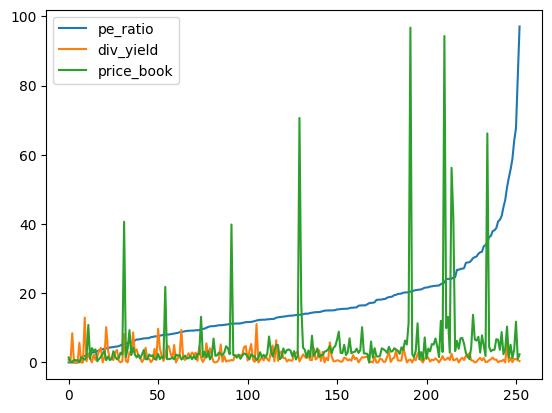

In [8]:
# Note that industry and sector lists contain other potentially useful stats eg PE / PS / PB ratios dividends etc
# These are calculated at the industry/sector level so give an indication of overall industries to watch...
# Stats are likely to be the latest so either run this quarterly and store historical numbers or just accept that this is a snapshot at moment industries were scraped
ind.sort_values(by='pe_ratio')[['pe_ratio','div_yield','price_book']].reset_index(drop=True).plot()

### Scrape all prices in a specified sector

In [9]:
MTScraper.sectors

,id,url,name
0,13,finance,Finance
1,4,medical,Medical
2,10,computer-and-technology,Computer and Technology
3,12,oils-energy,Oils/Energy
4,16,business-services,Business Services
5,1,consumer-staples,Consumer Staples
6,3,retail-wholesale,Retail/Wholesale
7,6,basic-materials,Basic Materials
8,14,utilities,Utilities
9,7,industrial-products,Industrial Products


### Scrape all reports in a specified sector

In [10]:
# This is quite slow - expensive to scrape prices for many companies
# Maybe only scrape prices when more detail is wanted based on other analysis
import random
tech = MTScraper.sectorTickers('Computer and Technology')
l = MTScraper.tickerlist.loc[tech]
l['last_update'].sort_values()

to_scrape = l['last_update'].sort_values()[0:2].index.to_list()
print('Scraping:', to_scrape)
for t in to_scrape:
    result = MTScraper.scrapeCompany(t)
    print(t, ': scraped Result:', result)
    if (result == 0):
        time.sleep(30 + random.randint(10,50))
        pass

Scraping: ['SMTC', 'GRMN']
Removing 0 duplicates for TICKERS
SMTC zacks_x_ind_desc    Semiconductor - Analog & Mixed
comp_name                                  semtech
comp_name_2                                Semtech
price_per_sales                               2.11
price_book                                    2.28
sector                     Computer and Technology
last_update                             2000-01-01
status                                           0
Name: SMTC, dtype: object
Type of last_updated: <class 'datetime.date'>   Type of recent_date: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
Casting to datetime: 2000-01-01 00:00:00
Ticker: SMTC Company: semtech
https://www.macrotrends.net/stocks/charts/SMTC/semtech/balance-sheet?freq=Q


C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.index = pd.to_datetime(df.index, errors='ignore')
C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.index = pd.to_datetime(df.index, errors='ignore')
C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.index = pd.to_datetime(df.index, errors='ignore')
C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and 

SMTC:: Report balanceq: 8 records written...
https://www.macrotrends.net/stocks/charts/SMTC/semtech/income-statement?freq=Q


C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.index = pd.to_datetime(df.index, errors='ignore')
C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.index = pd.to_datetime(df.index, errors='ignore')
C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.index = pd.to_datetime(df.index, errors='ignore')
C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and 

SMTC:: Report incq: 8 records written...
https://www.macrotrends.net/stocks/charts/SMTC/semtech/cash-flow-statement?freq=Q


...

GRMN:: Report incq: 9 records written...
https://www.macrotrends.net/stocks/charts/GRMN/garmin/cash-flow-statement?freq=Q


C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.index = pd.to_datetime(df.index, errors='ignore')
C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.index = pd.to_datetime(df.index, errors='ignore')
C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.index = pd.to_datetime(df.index, errors='ignore')
C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:252: FutureWarning: errors='ignore' is deprecated and 

GRMN:: Report cfq: 9 records written...
https://www.macrotrends.net/assets/php/stock_price_history.php?t=GRMN


C:\Users\Ben.Silburn\AppData\Local\Temp\ipykernel_14428\2989519570.py:179: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df['timestamp'] = pd.to_datetime(df['d'], errors='ignore')


529 price records added
GRMN : scraped Result: 0
